In [ ]:
import os
import pandas as pd
import pyodbc
import matplotlib.pyplot as plt
import seaborn as sns
from db_connection import conn, cursor

In [1]:
query = """
SELECT
    w.location_id,
    l.location,
    w.[date],
    w.rainfall,
    w.temperature,
    w.humidity,
    w.pressure,
    w.wind_speed,
    r.river_discharge,
    CASE 
        WHEN lb.date IS NOT NULL THEN 1
        ELSE 0
    END AS flood

FROM weather_data w
JOIN river_data r ON w.location_id = r.location_id
AND CAST(w.[date] AS DATE) = CAST(r.[date] AS DATE)

JOIN location_data l ON w.location_id = l.location_id

LEFT JOIN label_data lb 
ON w.date = lb.date
AND w.location_id = lb.location_id
"""

In [18]:
df = pd.read_sql(query, conn)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_476\1168034203.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [20]:
df.head(20)

,location_id,location,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood
0,1,Hue,2001-07-01,0.0,28.600000,68.0,1000.400024,24.799999,0.53,0
1,1,Hue,2001-07-02,0.2,29.100000,70.0,998.700012,20.900000,0.44,0
2,1,Hue,2001-07-03,1.8,28.600000,79.0,999.599976,6.900000,0.42,0
3,1,Hue,2001-07-04,13.8,27.799999,85.0,999.900024,11.500000,0.44,0
4,1,Hue,2001-07-05,0.0,28.799999,74.0,997.500000,25.200001,0.41,0
5,1,Hue,2001-07-06,0.0,29.799999,64.0,996.599976,28.100000,0.37,0
6,1,Hue,2001-07-07,0.5,30.200001,68.0,998.400024,23.100000,0.36,0
7,1,Hue,2001-07-08,38.0,28.400000,82.0,1003.099976,6.200000,0.70,0
8,1,Hue,2001-07-09,6.7,28.000000,80.0,1006.400024,8.100000,1.28,0
9,1,Hue,2001-07-10,0.2,28.200001,79.0,1006.200012,9.200000,0.92,0


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18286 entries, 0 to 18285
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   location_id      18286 non-null  int64  
 1   location         18286 non-null  object 
 2   date             18286 non-null  object 
 3   rainfall         18286 non-null  float64
 4   temperature      18286 non-null  float64
 5   humidity         18286 non-null  float64
 6   pressure         18286 non-null  float64
 7   wind_speed       18286 non-null  float64
 8   river_discharge  18286 non-null  float64
 9   flood            18286 non-null  int64  
dtypes: float64(6), int64(2), object(2)
memory usage: 1.4+ MB


In [22]:
df["date"] =pd.to_datetime(df["date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18286 entries, 0 to 18285
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   location_id      18286 non-null  int64         
 1   location         18286 non-null  object        
 2   date             18286 non-null  datetime64[ns]
 3   rainfall         18286 non-null  float64       
 4   temperature      18286 non-null  float64       
 5   humidity         18286 non-null  float64       
 6   pressure         18286 non-null  float64       
 7   wind_speed       18286 non-null  float64       
 8   river_discharge  18286 non-null  float64       
 9   flood            18286 non-null  int64         
dtypes: datetime64[ns](1), float64(6), int64(2), object(1)
memory usage: 1.4+ MB


In [23]:
df.describe()

,location_id,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood
count,18286.000000,18286,18286.000000,18286.000000,18286.000000,18286.000000,18286.000000,18286.000000,18286.000000
mean,1.500000,2014-01-05 00:00:00,7.876736,25.758537,83.012851,1009.344411,14.339380,23.587589,0.035984
min,1.000000,2001-07-01 00:00:00,0.000000,14.100000,45.000000,984.400024,4.200000,0.080000,0.000000
25%,1.000000,2007-10-03 06:00:00,0.200000,23.299999,80.000000,1005.299988,11.300000,0.670000,0.000000
50%,1.500000,2014-01-05 00:00:00,2.200000,26.000000,84.000000,1009.000000,13.600000,6.530000,0.000000
75%,2.000000,2020-04-08 18:00:00,8.400000,28.400000,88.000000,1013.299988,16.600000,14.850000,0.000000
max,2.000000,2026-07-12 00:00:00,398.799988,34.599998,97.000000,1028.400024,64.599998,1569.359985,1.000000
std,0.500014,NaN,16.872527,3.285306,7.064243,5.201703,4.613390,68.787972,0.186255


### Lấy dir output

In [8]:
#lấy đường dẫn của file hiện tại
cur_dir = os.getcwd()

#tạo đường dẫn đến output
output_path = os.path.join(cur_dir, "..", "output")

# chuyển đường dẫn thành đường dẫn tuyệt đối
output_path = os.path.abspath(output_path)

print(output_path)

d:\FPT\Kì 3\ADY201m\Project\Flood Prediction\output


In [24]:
df['month'] = df['date'].dt.month

In [25]:
def get_season(month):
    if month in [5, 6, 7, 8, 9, 10]:
        return "Rainy"
    else:
        return "Dry"

df["season"] = df["month"].apply(get_season)

### Rainfall 3 days

In [26]:
df['rainfall_3days'] = df.groupby('location_id')['rainfall'].transform(
    lambda x: x.rolling(window=3, min_periods=1).sum()
)
    
df.head(10)

,location_id,location,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood,month,season,rainfall_3days
0,1,Hue,2001-07-01,0.0,28.600000,68.0,1000.400024,24.799999,0.53,0,7,Rainy,0.0
1,1,Hue,2001-07-02,0.2,29.100000,70.0,998.700012,20.900000,0.44,0,7,Rainy,0.2
2,1,Hue,2001-07-03,1.8,28.600000,79.0,999.599976,6.900000,0.42,0,7,Rainy,2.0
3,1,Hue,2001-07-04,13.8,27.799999,85.0,999.900024,11.500000,0.44,0,7,Rainy,15.8
4,1,Hue,2001-07-05,0.0,28.799999,74.0,997.500000,25.200001,0.41,0,7,Rainy,15.6
5,1,Hue,2001-07-06,0.0,29.799999,64.0,996.599976,28.100000,0.37,0,7,Rainy,13.8
6,1,Hue,2001-07-07,0.5,30.200001,68.0,998.400024,23.100000,0.36,0,7,Rainy,0.5
7,1,Hue,2001-07-08,38.0,28.400000,82.0,1003.099976,6.200000,0.70,0,7,Rainy,38.5
8,1,Hue,2001-07-09,6.7,28.000000,80.0,1006.400024,8.100000,1.28,0,7,Rainy,45.2
9,1,Hue,2001-07-10,0.2,28.200001,79.0,1006.200012,9.200000,0.92,0,7,Rainy,44.9


### Rainfall 7 days

In [27]:
df['rainfall_7days'] = df.groupby('location_id')['rainfall'].transform(
    lambda x: x.rolling(window=7, min_periods=1).sum()
)
df.head(10)

,location_id,location,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood,month,season,rainfall_3days,rainfall_7days
0,1,Hue,2001-07-01,0.0,28.600000,68.0,1000.400024,24.799999,0.53,0,7,Rainy,0.0,0.0
1,1,Hue,2001-07-02,0.2,29.100000,70.0,998.700012,20.900000,0.44,0,7,Rainy,0.2,0.2
2,1,Hue,2001-07-03,1.8,28.600000,79.0,999.599976,6.900000,0.42,0,7,Rainy,2.0,2.0
3,1,Hue,2001-07-04,13.8,27.799999,85.0,999.900024,11.500000,0.44,0,7,Rainy,15.8,15.8
4,1,Hue,2001-07-05,0.0,28.799999,74.0,997.500000,25.200001,0.41,0,7,Rainy,15.6,15.8
5,1,Hue,2001-07-06,0.0,29.799999,64.0,996.599976,28.100000,0.37,0,7,Rainy,13.8,15.8
6,1,Hue,2001-07-07,0.5,30.200001,68.0,998.400024,23.100000,0.36,0,7,Rainy,0.5,16.3
7,1,Hue,2001-07-08,38.0,28.400000,82.0,1003.099976,6.200000,0.70,0,7,Rainy,38.5,54.3
8,1,Hue,2001-07-09,6.7,28.000000,80.0,1006.400024,8.100000,1.28,0,7,Rainy,45.2,60.8
9,1,Hue,2001-07-10,0.2,28.200001,79.0,1006.200012,9.200000,0.92,0,7,Rainy,44.9,59.2


### River Level Change

In [30]:
df['river_discharge_change'] = df.groupby('location_id')['river_discharge'].diff()
df['river_discharge_change'] = df['river_discharge_change'].fillna(0)
df.head(10)

,location_id,location,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood,month,season,rainfall_3days,rainfall_7days,river_discharge_change
0,1,Hue,2001-07-01,0.0,28.600000,68.0,1000.400024,24.799999,0.53,0,7,Rainy,0.0,0.0,0.00
1,1,Hue,2001-07-02,0.2,29.100000,70.0,998.700012,20.900000,0.44,0,7,Rainy,0.2,0.2,-0.09
2,1,Hue,2001-07-03,1.8,28.600000,79.0,999.599976,6.900000,0.42,0,7,Rainy,2.0,2.0,-0.02
3,1,Hue,2001-07-04,13.8,27.799999,85.0,999.900024,11.500000,0.44,0,7,Rainy,15.8,15.8,0.02
4,1,Hue,2001-07-05,0.0,28.799999,74.0,997.500000,25.200001,0.41,0,7,Rainy,15.6,15.8,-0.03
5,1,Hue,2001-07-06,0.0,29.799999,64.0,996.599976,28.100000,0.37,0,7,Rainy,13.8,15.8,-0.04
6,1,Hue,2001-07-07,0.5,30.200001,68.0,998.400024,23.100000,0.36,0,7,Rainy,0.5,16.3,-0.01
7,1,Hue,2001-07-08,38.0,28.400000,82.0,1003.099976,6.200000,0.70,0,7,Rainy,38.5,54.3,0.34
8,1,Hue,2001-07-09,6.7,28.000000,80.0,1006.400024,8.100000,1.28,0,7,Rainy,45.2,60.8,0.58
9,1,Hue,2001-07-10,0.2,28.200001,79.0,1006.200012,9.200000,0.92,0,7,Rainy,44.9,59.2,-0.36


### Histogram

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_476\2889640159.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df['rainfall'], bins=100, palette='Oranges')


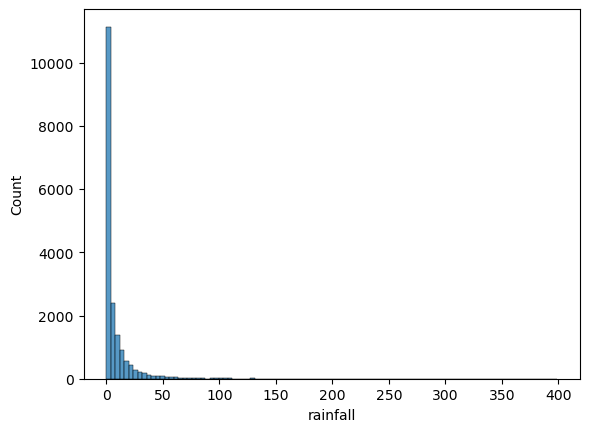

In [31]:
sns.histplot(data=df['rainfall'], bins=100, palette='Oranges')
image_path = os.path.join(output_path, "histogram_rainfall.png")

* biểu đồ lệch phải: 
    - phần lớn tập trung ở 0-10 mm
    - đa số ngày có lượng mưa thấp hoặc không mưa
    - chỉ có 1 số ngày mưa lớn
* mưa lớn là sự kiện hiếm:
    - 0-10 mm: rất nhiều
    - 10-vô tận: cực ít
* có outliers:
    - phân bố tới 150mm, 200mm

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_23332\4141902024.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df['river_discharge'], bins=100, palette='Oranges')


<Axes: xlabel='river_discharge', ylabel='Count'>

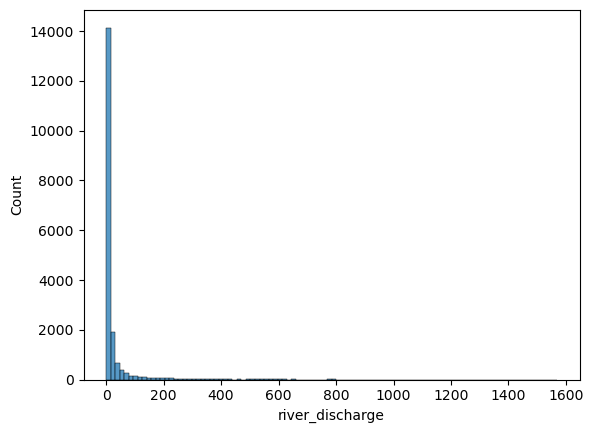

In [94]:
sns.histplot(data=df['river_discharge'], bins=100, palette='Oranges')

### Boxplot chuẩn hóa để dễ so sánh

<Axes: ylabel='rainfall'>

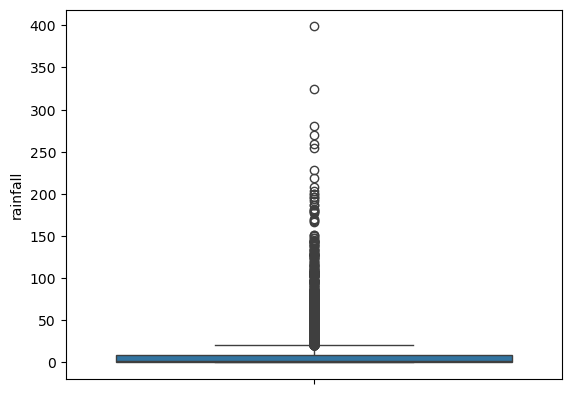

In [95]:
sns.boxplot(df['rainfall'])

<Axes: ylabel='river_discharge'>

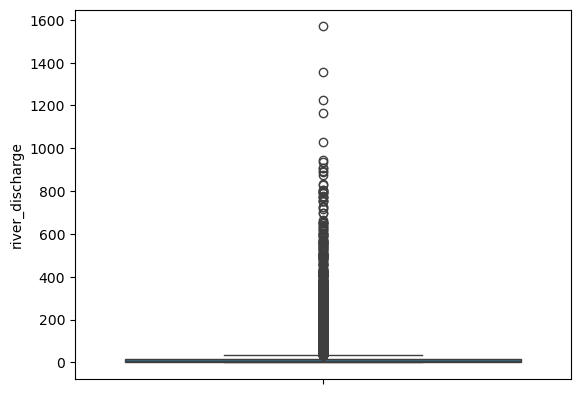

In [96]:
sns.boxplot(df['river_discharge'])

<Axes: xlabel='rainfall', ylabel='river_discharge'>

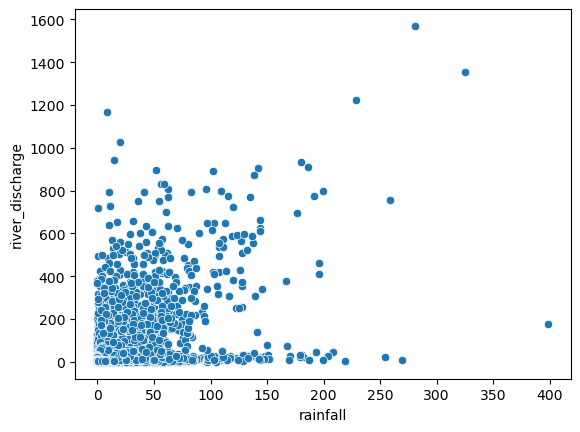

In [97]:
sns.scatterplot(
    data=df,
    x="rainfall",
    y="river_discharge"
)

#### linegraph

In [98]:
rainfall_year = (df.groupby(df['date'].dt.year)['rainfall'].mean().reset_index())

rainfall_year.head()

,date,rainfall
0,2001,7.759315
1,2002,6.873973
2,2003,7.147123
3,2004,5.797678
4,2005,8.390548


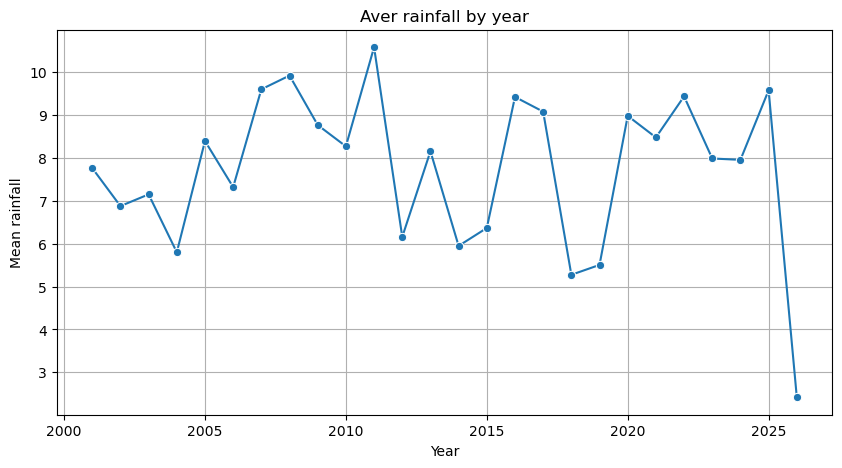

In [99]:

plt.figure(figsize=(10,5))

sns.lineplot(
    data=rainfall_year,
    x='date',
    y='rainfall',
    marker='o'
)

plt.title("Aver rainfall by year")
plt.xlabel('Year')
plt.ylabel('Mean rainfall')
plt.grid(True)

plt.show()

<Axes: >

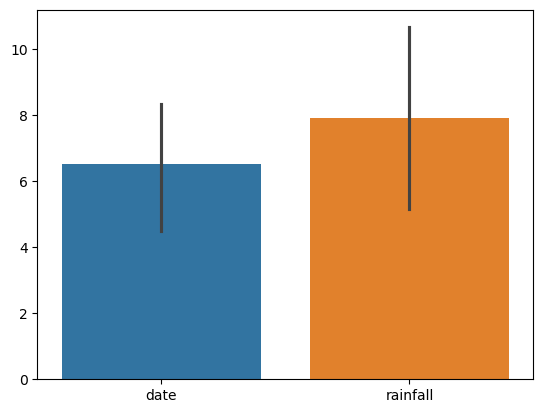

In [100]:
sns.barplot(df.groupby(df['date'].dt.month)['rainfall'].mean().reset_index())

### heatmap

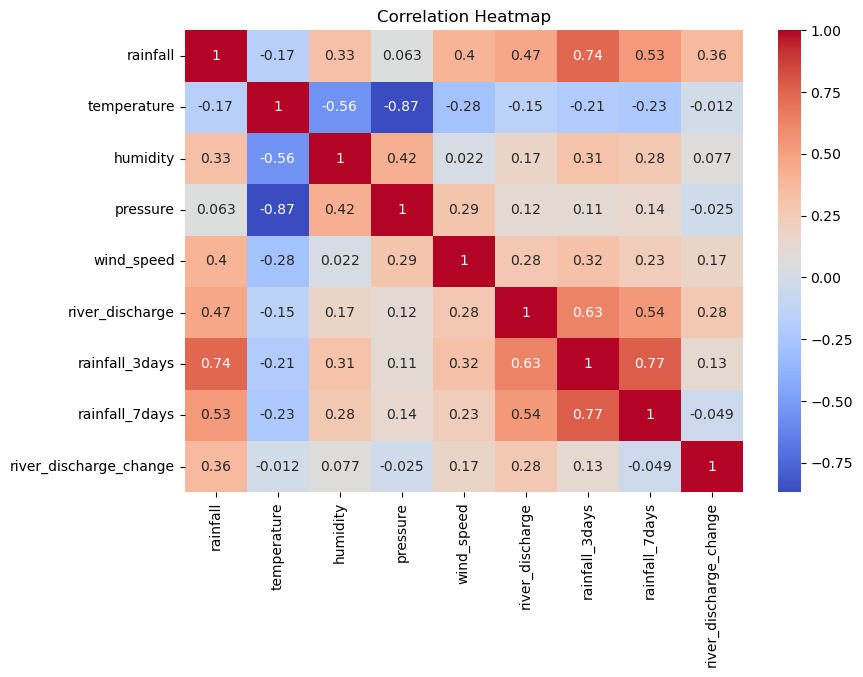

In [ ]:
numeric_cols = [
    'rainfall',
    'temperature',
    'humidity',
    'pressure',
    'wind_speed',
    'river_discharge',
    'rainfall_3days',
    'rainfall_7days', 
    'river_discharge_change'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")

plt.show()
plt.close()

### Scatter Plot: Rainfall vs River Discharge
#### Xem mưa nhiều có làm nước sông tăng không
#### Dùng để tìm correlation

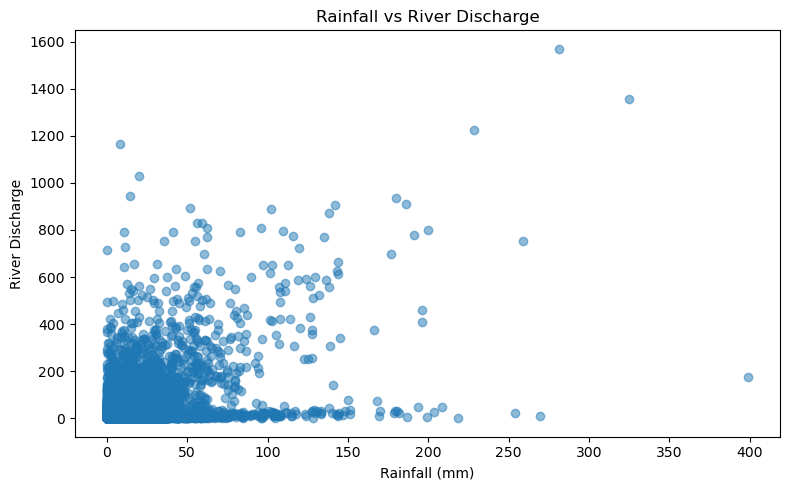

In [102]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["rainfall"],
    df["river_discharge"],
    alpha=0.5
)


plt.title("Rainfall vs River Discharge")

plt.xlabel("Rainfall (mm)")
plt.ylabel("River Discharge")


plt.tight_layout()

plt.show()
plt.close()

In [103]:
df.head(20)

,location_id,location,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,month,season,rainfall_3days,rainfall_7days,river_discharge_change
0,1,Hue,2001-01-01,2.600000,20.200001,82.0,1013.299988,9.600000,1.56,1,Dry,2.600000,2.600000,0.00
1,1,Hue,2001-01-02,0.000000,21.100000,82.0,1011.799988,14.100000,1.09,1,Dry,2.600000,2.600000,-0.47
2,1,Hue,2001-01-03,1.000000,21.600000,85.0,1012.900024,12.700000,0.75,1,Dry,3.600000,3.600000,-0.34
3,1,Hue,2001-01-04,6.700000,21.200001,91.0,1014.200012,15.500000,0.72,1,Dry,7.700000,10.300000,-0.03
4,1,Hue,2001-01-05,4.800000,22.100000,90.0,1014.000000,14.500000,0.92,1,Dry,12.500000,15.100000,0.20
5,1,Hue,2001-01-06,0.100000,22.900000,87.0,1013.000000,14.400000,0.75,1,Dry,11.600000,15.200000,-0.17
6,1,Hue,2001-01-07,0.100000,23.200001,87.0,1011.500000,14.900000,0.56,1,Dry,5.000000,15.300000,-0.19
7,1,Hue,2001-01-08,0.000000,23.400000,86.0,1009.500000,11.500000,0.47,1,Dry,0.200000,12.700000,-0.09
8,1,Hue,2001-01-09,0.000000,23.000000,88.0,1010.299988,15.200000,0.42,1,Dry,0.100000,12.700000,-0.05
9,1,Hue,2001-01-10,3.100000,22.799999,87.0,1011.400024,15.400000,0.39,1,Dry,3.100000,14.800000,-0.03


In [104]:
output_path = '../data/train/master_weather.csv'

# Export CSV
df.to_csv(output_path, index=False)

print('Done')

Done
